# 业务报表可视化实战练习

请先运行“图表数据准备”代码单元，再完成各题。

覆盖知识点：折线图、柱状图、条形图、饼图、环形图、爆炸式饼图、散点图、箱线图、直方图、子图布局，以及标题、坐标轴、图例、网格、颜色、字体、刻度、文本标注、`tight_layout`。


## 场景

你在企业 BI 团队负责月度经营分析会，需要使用 `matplotlib` 输出多种报表图。题目中的指标均是教学用模拟数据，但图表要求尽量贴近真实工作报表。


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pathlib import Path

# 设置中文字体
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
rcParams['axes.unicode_minus'] = False

monthly_kpi = pd.DataFrame({
    'month': ['1月', '2月', '3月', '4月', '5月', '6月'],
    'actual_revenue': [320, 355, 338, 402, 438, 465],
    'target_revenue': [300, 340, 350, 390, 420, 450],
    'orders': [4200, 4550, 4380, 5020, 5480, 5750]
})

category_sales = pd.DataFrame({
    'category': ['数码', '家电', '食品', '美妆', '日用'],
    'sales': [520, 430, 210, 360, 295]
})

city_revenue = pd.DataFrame({
    'city': ['上海', '北京', '深圳', '广州', '杭州'],
    'revenue': [680, 620, 540, 460, 430]
})

channel_share = pd.DataFrame({
    'channel': ['App', '小程序', '门店', '直播'],
    'revenue_share': [42, 21, 19, 18]
})

complaint_reason = pd.DataFrame({
    'reason': ['发货慢', '包装破损', '商品错发', '客服响应慢', '其他'],
    'count': [38, 16, 9, 21, 11]
})

refund_reason = pd.DataFrame({
    'reason': ['质量问题', '价格波动', '物流超时', '重复下单', '其他'],
    'count': [44, 18, 26, 9, 7]
})

ad_effect = pd.DataFrame({
    'ad_spend': [3.2, 4.1, 4.8, 5.6, 6.4, 7.1, 7.9, 8.3],
    'order_count': [180, 205, 228, 244, 269, 291, 305, 318]
})

order_amount_distribution = {
    '数码': [4999, 5299, 6999, 3899, 4599, 6299, 5599, 4799],
    '家电': [1299, 1599, 2199, 2599, 1799, 2899, 1999, 2399],
    '美妆': [199, 259, 299, 219, 329, 279, 249, 359]
}

weather_report = pd.DataFrame({
    'date': pd.date_range('2025-01-01', periods=30, freq='D'),
    'temp_max': [8, 9, 11, 12, 10, 13, 14, 15, 11, 10, 9, 12, 13, 16, 17, 18, 15, 14, 13, 12, 11, 13, 14, 15, 16, 18, 19, 17, 16, 15],
    'temp_min': [1, 2, 3, 4, 3, 5, 6, 7, 3, 2, 1, 4, 5, 7, 8, 9, 6, 5, 4, 3, 2, 4, 5, 6, 7, 8, 9, 7, 6, 5],
    'precipitation': [0, 0, 0.2, 0, 1.1, 2.4, 0, 0, 3.2, 0, 0, 0.5, 0, 0, 1.8, 0, 0, 4.2, 0.3, 0, 0, 0, 1.2, 0, 0, 2.6, 0, 0, 0.8, 0]
})

print('图表数据准备完成')
monthly_kpi.head()


图表数据准备完成


,month,actual_revenue,target_revenue,orders
0,1月,320,300,4200
1,2月,355,340,4550
2,3月,338,350,4380
3,4月,402,390,5020
4,5月,438,420,5480


## 第 1 题：月度营收趋势折线图

业务要求：经营分析会要对比“实际营收”和“目标营收”的趋势。

请使用 `monthly_kpi` 绘制一张折线图，要求：

1. 同时绘制 `actual_revenue` 与 `target_revenue` 两条线。
2. 设置标题、x/y 轴标签、图例、网格线。
3. 设置线条颜色、线型、标记点。
4. 给每个 `actual_revenue` 数据点添加数值标签。
5. 合理设置 `ylim`。


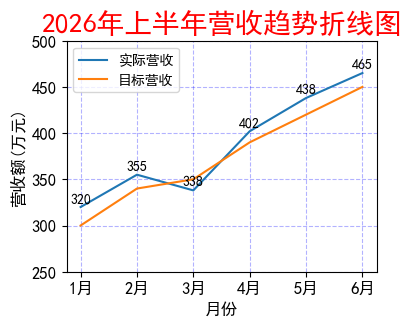

In [102]:
# 设置图表的尺寸
plt.figure(figsize=(4, 3))
# 绘制actual_revenue和target_revenue两条线
plt.plot(monthly_kpi['month'], monthly_kpi['actual_revenue'], label='实际营收', color='tab:blue')
plt.plot(monthly_kpi['month'], monthly_kpi['target_revenue'], label='目标营收', color='tab:orange')
# 设置标题，x/y轴标签，图例，网格线
plt.title('2026年上半年营收趋势折线图', fontsize=20, color='red')
plt.xlabel('月份', fontsize=12)
plt.ylabel('营收额(万元)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left')
plt.grid(linestyle='--', alpha=0.3, color='blue')
# 为每个actual_revenue数据点添加数值标签
for x,y in zip(monthly_kpi['month'], monthly_kpi['actual_revenue']):
    plt.text(x, y+3, str(y), ha='center', va='bottom', fontsize=10)
# 设置ylim
plt.ylim(250,500)
# 展示图表
plt.show()


## 第 2 题：品类销售额柱状图

业务要求：品类经理要查看各品类销售额对比。

请使用 `category_sales` 绘制柱状图，要求：

1. 自定义柱体颜色和宽度。
2. 设置标题、坐标轴标签。
3. 只显示 y 轴网格线。
4. 在每个柱体顶部标注销售额。
5. 使用 `tight_layout()` 优化排版。


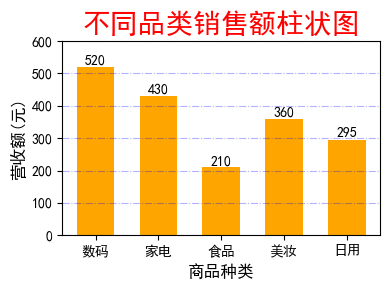

In [103]:
# 使用category_sales绘制柱状图
# 设置画布尺寸
plt.figure(figsize=(4,3))
# 自定义柱体颜色和宽度
plt.bar(category_sales['category'], category_sales['sales'], color='orange', width=0.6)
# 设置标题、坐标轴
plt.title('不同品类销售额柱状图', fontsize=20, color='red')
plt.xlabel('商品种类', fontsize=12)
plt.ylabel('营收额(元)', fontsize=12)
plt.ylim(0, 600)
# 只显示y轴网格线
plt.grid(linestyle='-.', alpha=0.3, color='blue', axis='y')
# 每个柱体顶部标注销售额
for x,y in zip(category_sales['category'], category_sales['sales']):
    plt.text(x, y+1, str(y), ha='center', va='bottom', fontsize=10)
# 使用tight_layout()优化排版
plt.tight_layout()
# 展示表格
plt.show()


## 第 3 题：城市营收排名条形图

业务要求：区域总监习惯看横向排名图。

请使用 `city_revenue` 绘制一张条形图（横向柱状图），展示不同城市营收排名，并补充标题与坐标轴标签。


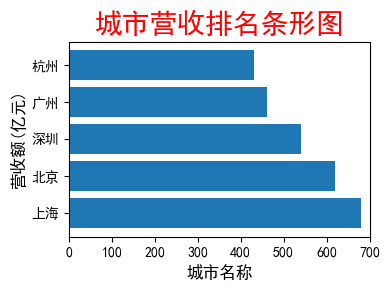

In [104]:
# 使用city_revenue绘制条形图
# 设置画布尺寸
plt.figure(figsize=(4,3))
plt.barh(city_revenue['city'], city_revenue['revenue'])
# 设置标题、坐标轴
plt.title('城市营收排名条形图', fontsize=20, color='red')
plt.xlabel('城市名称', fontsize=12)
plt.ylabel('营收额(亿元)', fontsize=12)
plt.xlim(0, 700)
# 使用tight_layout()优化排版
plt.tight_layout()
# 展示表格
plt.show()


## 第 4 题：渠道收入占比饼图

业务要求：渠道负责人要看收入构成。

请使用 `channel_share` 绘制饼图，要求：

1. 显示百分比。
2. 自定义颜色。
3. 设置起始角度。
4. 添加标题。


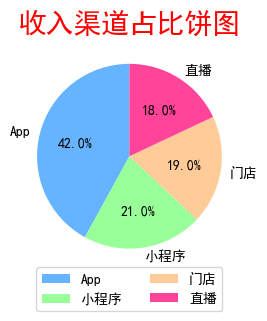

In [105]:
# 使用channel_share绘制饼图
# 自定义颜色
colors = ['#66b3ff','#99ff99','#ffcc99','#ff4499']
# 设置画布尺寸
plt.figure(figsize=(4,3))
plt.pie(channel_share['revenue_share'], labels=channel_share['channel'],
        colors=colors, autopct='%.1f%%', startangle=90)
# 设置标题
plt.title('收入渠道占比饼图', fontsize=20, color='red')
plt.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.2))
# 展示表格
plt.show()

## 第 5 题：客诉原因环形图

业务要求：客服部要在周会上展示客诉结构，但希望图表更适合做汇报封面。

请使用 `complaint_reason` 绘制环形图，要求：

1. 在 `plt.pie()` 中通过 `wedgeprops` 设置圆环宽度。
2. 显示百分比。
3. 在图中央补一段汇总文本，例如“本月客诉”。


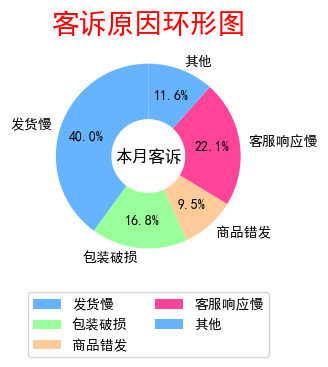

In [106]:
# 使用complaint_reason绘制饼图
# 自定义颜色
colors = ['#66b3ff','#99ff99','#ffcc99','#ff4499']
# 设置画布尺寸(wedgeprops圆环挖空半径占比，pctdistance百分比距离圆心距离/半径)
plt.figure(figsize=(4,3))
plt.pie(complaint_reason['count'], labels=complaint_reason['reason'],
        colors=colors, autopct='%.1f%%', startangle=90,
        wedgeprops={'width': 0.6}, pctdistance=0.7)
# 设置标题
plt.title('客诉原因环形图', fontsize=20, color='red')
# 图中央补一段汇总文本
plt.text(0, 0, '本月客诉', ha='center', va='center', fontsize=12)
plt.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.4))
# 展示表格
plt.show()

## 第 6 题：退款原因爆炸式饼图

业务要求：退款分析中需要重点突出“质量问题”。

请使用 `refund_reason` 绘制爆炸式饼图，要求：

1. 仅让“质量问题”对应的扇区突出。
2. 添加阴影。
3. 显示标题和百分比。


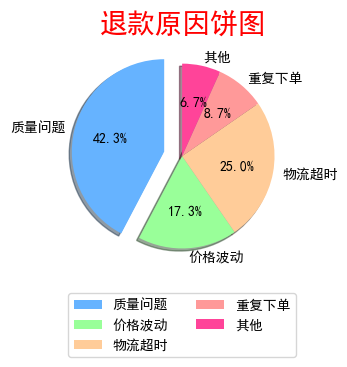

In [107]:
# 使用refund_reason绘制饼图
# 自定义颜色
colors = ['#66b3ff','#99ff99','#ffcc99','#ff9999','#ff4499']
# 设置画布尺寸
plt.figure(figsize=(4,3))
explode = [0.2, 0, 0, 0, 0]
# wedgeprops圆环挖空半径占比，pctdistance百分比距离圆心距离/半径, explode突出某块饼图, shadow添加阴影
plt.pie(refund_reason['count'], labels=refund_reason['reason'],
        colors=colors, autopct='%.1f%%', startangle=90,
        explode=explode, shadow=True)
# 设置标题
plt.title('退款原因饼图', fontsize=20, color='red')
plt.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.4))
# 展示表格
plt.show()

## 第 7 题：广告投放与订单量散点图

业务要求：市场部怀疑广告投放和订单量存在正相关。

请使用 `ad_effect` 绘制散点图，展示 `ad_spend` 与 `order_count` 的关系，并设置标题、坐标轴标签。


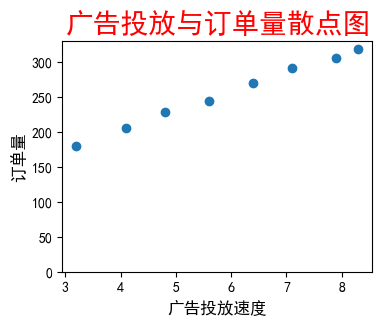

In [108]:
# 使用ad_affect绘制散点图
# 设置图表的尺寸
plt.figure(figsize=(4, 3))
# 绘制散点图
plt.scatter(ad_effect['ad_spend'], ad_effect['order_count'])
# 设置标题，x/y轴标签
plt.title('广告投放与订单量散点图', fontsize=20, color='red')
plt.xlabel('广告投放速度', fontsize=12)
plt.ylabel('订单量', fontsize=12)
# 设置纵坐标的范围
plt.ylim(0, 330)
# 展示图表
plt.show()



## 第 8 题：不同品类订单金额箱线图

业务要求：风控团队要查看不同品类订单金额的分布和异常值情况。

请基于 `order_amount_distribution` 绘制箱线图，并添加标题、y 轴标签和 y 轴网格线。


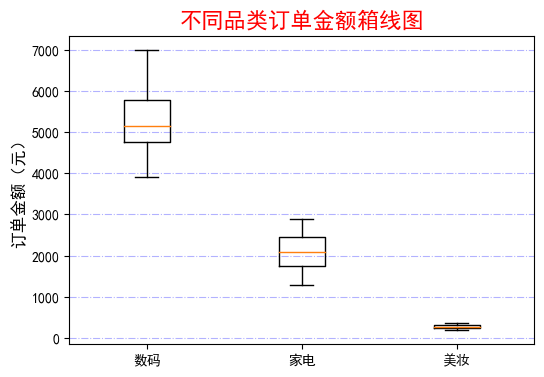

In [109]:
# 根据order_amount_distribution绘制箱线图
plt.figure(figsize=(6,4))
plt.boxplot(order_amount_distribution.values(), labels=order_amount_distribution.keys())
# 添加标题、y轴标签、y轴网格线
plt.title('不同品类订单金额箱线图', fontsize=16, color='red')
plt.ylabel('订单金额（元）', fontsize=12)
plt.grid(linestyle='-.', alpha=0.3, color='blue', axis='y')
plt.show()


## 第 9 题：降水量直方图

业务要求：线下门店团队想了解一个月内降水量的分布情况。

请使用 `weather_report` 的 `precipitation` 绘制直方图，要求：

1. 指定分箱数。
2. 设置标题和坐标轴标签。
3. 选择一个清晰的颜色。


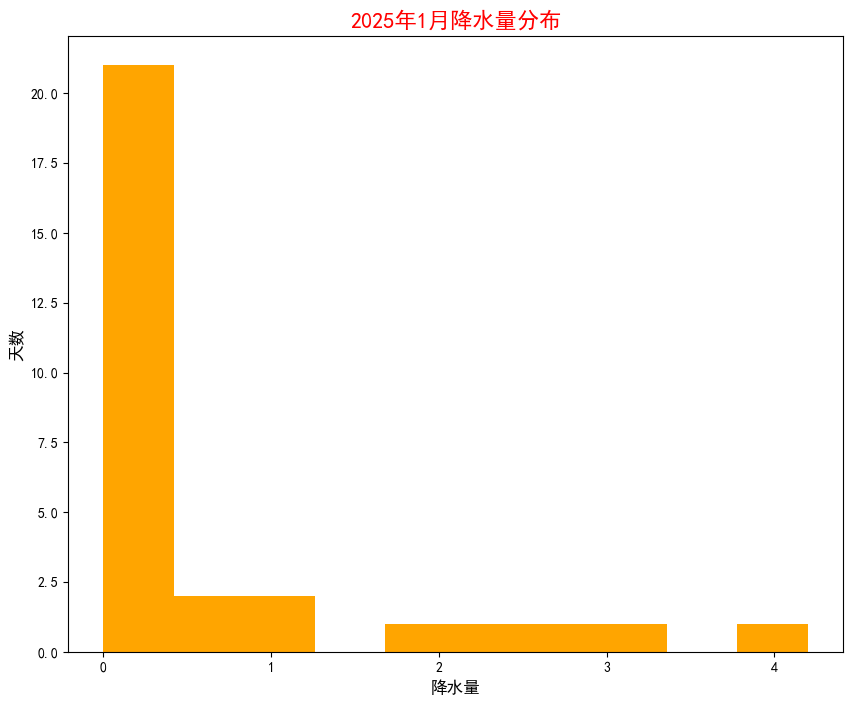

In [110]:
# 使用weather_report的precipitation绘制直方图
plt.figure(figsize=(10, 8))
# 指定分箱数
plt.hist(weather_report['precipitation'], bins=10, color='orange')
# 设置标题和坐标轴标签
plt.title('2025年1月降水量分布', fontsize=16, color='red')
plt.xlabel('降水量', fontsize=12)
plt.ylabel('天数', fontsize=12)
# 展示图表
plt.show()

## 第 10 题：四宫格经营看板

业务要求：你要在一页 PPT 中放下四张图，快速展示经营全貌。

请使用 `subplot` 或 `subplots` 生成 2 行 2 列布局，至少包含以下 4 类图表中的 4 个：

- 折线图
- 柱状图
- 散点图
- 条形图
- 饼图

要求整体排版清晰，并尽量补充标题。


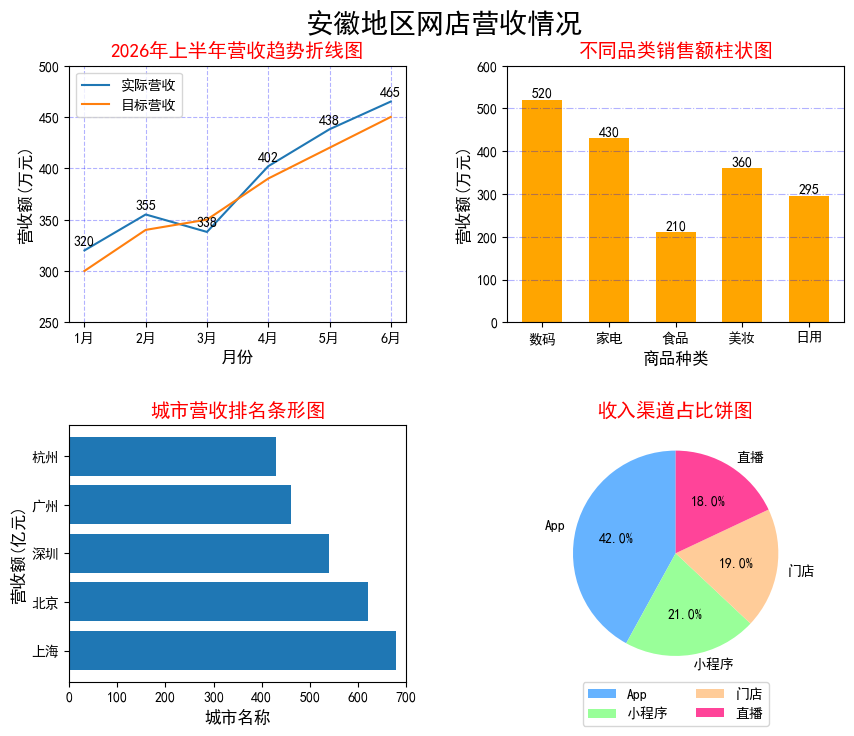

In [128]:
# 创建2*2子图布局
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,8), dpi=100)
assert isinstance(fig, Figure)
# 大标题
fig.suptitle('安徽地区网店营收情况', fontsize=20, x=0.5, y=0.95)
# 调节子图间距
fig.subplots_adjust(wspace=0.3, hspace=0.4)

# 折线图
# 绘制actual_revenue和target_revenue两条线
ax1: Axes = axes[0, 0]
ax1.plot(monthly_kpi['month'], monthly_kpi['actual_revenue'], label='实际营收', color='tab:blue')
ax1.plot(monthly_kpi['month'], monthly_kpi['target_revenue'], label='目标营收', color='tab:orange')
# 设置标题，x/y轴标签，图例，网格线
ax1.set_title('2026年上半年营收趋势折线图', fontsize=14, color='red')
ax1.set_xlabel('月份', fontsize=12)
ax1.set_ylabel('营收额(万元)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(linestyle='--', alpha=0.3, color='blue')
# 为每个actual_revenue数据点添加数值标签
for x,y in zip(monthly_kpi['month'], monthly_kpi['actual_revenue']):
    ax1.text(x, y+3, str(y), ha='center', va='bottom', fontsize=10)
# 设置ylim
ax1.set_ylim(250,500)

# 柱状图
ax2: Axes = axes[0, 1]
# 自定义柱体颜色和宽度
ax2.bar(category_sales['category'], category_sales['sales'], color='orange', width=0.6)
# 设置标题、坐标轴
ax2.set_title('不同品类销售额柱状图', fontsize=14, color='red')
ax2.set_xlabel('商品种类', fontsize=12)
ax2.set_ylabel('营收额(万元)', fontsize=12)
ax2.set_ylim(0, 600)
# 只显示y轴网格线
ax2.grid(linestyle='-.', alpha=0.3, color='blue', axis='y')
# 每个柱体顶部标注销售额
for x,y in zip(category_sales['category'], category_sales['sales']):
    ax2.text(x, y+1, str(y), ha='center', va='bottom', fontsize=10)

# 条形图
ax3: Axes = axes[1, 0]
ax3.barh(city_revenue['city'], city_revenue['revenue'])
# 设置标题、坐标轴
ax3.set_title('城市营收排名条形图', fontsize=14, color='red')
ax3.set_xlabel('城市名称', fontsize=12)
ax3.set_ylabel('营收额(亿元)', fontsize=12)
ax3.set_xlim(0, 700)

# 饼状图
ax4: Axes = axes[1, 1]
# 自定义颜色
colors = ['#66b3ff','#99ff99','#ffcc99','#ff4499']
ax4.pie(channel_share['revenue_share'], labels=channel_share['channel'],
        colors=colors, autopct='%.1f%%', startangle=90)
# 设置标题
ax4.set_title('收入渠道占比饼图', fontsize=14, color='red')
ax4.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.2))

# 保存图片
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)
plt.savefig(OUTPUT_DIR/'pic1.png')
# 展示图表
plt.show()


## 第 11 题：天气趋势组合图

业务要求：门店运营希望同时看到 30 天内最高温、最低温的变化趋势。

请使用 `weather_report` 绘制双折线图，要求：

1. 横轴为 `date`。
2. 同时绘制 `temp_max` 和 `temp_min`。
3. 设置标题、图例、坐标轴标签。
4. 适当设置图表尺寸。


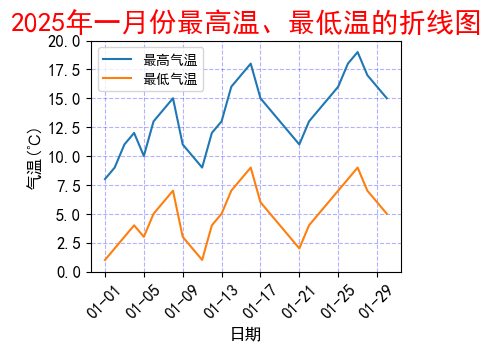

In [135]:
# 使用weather_report绘制双折线图
# 设置图表的尺寸
plt.figure(figsize=(4, 3))
# 将日期改成"月份-日期的字符串"
x_dates = weather_report['date'].dt.strftime('%m-%d')
plt.plot(x_dates, weather_report['temp_max'], label='最高气温', color='tab:blue')
plt.plot(x_dates, weather_report['temp_min'], label='最低气温', color='tab:orange')
# 设置标题，x/y轴标签，图例，网格线
plt.title('2025年一月份最高温、最低温的折线图', fontsize=20, color='red')
plt.xlabel('日期', fontsize=12)
plt.ylabel('气温(℃)', fontsize=12)
plt.xticks(ticks=range(0, len(x_dates), 4), labels=x_dates[::4] ,fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.legend(loc='upper left')
plt.grid(linestyle='--', alpha=0.3, color='blue')
# 设置ylim
plt.ylim(0, 20)
# 展示图表
plt.show()



## 第 12 题：选择图表类型并说明理由

业务要求：你要给新同事解释为什么不同业务问题要用不同图。

请在 Markdown 中回答：

1. 趋势分析为什么更适合折线图。
2. 类别比较为什么常用柱状图/条形图。
3. 分布分析为什么适合箱线图或直方图。
4. 比例分析为什么常用饼图。


1.折线图能够清晰的展示出数据的变化趋势（例如上升、下降），因此趋势分析适合用折线图
2.柱状图通过长短不一的柱子展示不同类别数值的大小，因此类别比较常用柱状图/条形图
3.对于数据的集中程度、异常值的分析适合用箱线图；而对于数据的分布和频率更适合用直方图
4.饼图通过不同面积的对比可以直观地进行比例分析，因此比例分析常用饼图
